# t0211: Elsys tpc5 (ECR dual mode) → Labquake Explorer HDF5

Preprocessing for an experiment recorded entirely on the Elsys TranAX system.
Each run is one `.tpc5` file in ECR *dual* mode: **block 1** is the continuous
2 kHz record of the whole run, **blocks 2…N** are 2 MHz records around each PZT
trigger (0.1 s before, 0.5 s after), all on one clock.

The run's time history comes from block 1; the file itself is kept as a raw-data
reference (`run['elsys']`) so that **Extract Events** in the explorer reads the
2 MHz trigger block that contains each picked event.

Run sheet (2026-08-28, 21 °C, 58 % RH, flow rate 8 ml/min, operator 朱宸潁):

| Elsys channel | sensor        | input range (Elsys setting) |
|---------------|---------------|-----------------------------|
| A1–A4         | PZT           | ±1 V (run1), ±0.5 V (run2–5), ±0.25 V (run6) |
| A5, A6        | pressure      | 0–10 V                      |
| A7            | LVDT          | −6 to 14 V                  |
| B1–B8         | eddy current  | ±25 V                       |

Runs: 01 8 MPa, 02 10 MPa, 03 12 MPa, 04 14 MPa, 05 16 MPa, 06 8 MPa.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))   # repository root, if not pip-installed
from labquake_explorer.data.data_manager import DataManager
from labquake_explorer.data.sources import Tpc5Source, NINpzSource, open_source, run_sources
from labquake_explorer.data.channels import get_channel, aligned_fields
from labquake_explorer.preprocessing import (
    Calibration, EddySlip, Linear, Friction, pressure_transducers, experiment,
    run_from_tpc5, run_from_tpc5_ni, slip_step_table,
)

## Paths

In [2]:
EXPERIMENT = 't0211'
EXPERIMENT_DIR = Path('/Users/hueyke/Library/CloudStorage/SynologyDrive-data/Experiment/T0211')
DATA_DIR = EXPERIMENT_DIR / f'{EXPERIMENT}.exp' / 'data'

# Output read by Labquake Explorer; raw-file paths are stored relative to it, so keep it next to the data.
OUTPUT_FILE = EXPERIMENT_DIR / f'{EXPERIMENT}.h5'

RUN_FILES = sorted(DATA_DIR.glob(f'{EXPERIMENT}_*.tpc5'))
for p in RUN_FILES:
    print(f'{p.stat().st_size / 1e6:8.1f} MB  {p.name}')

   834.8 MB  t0211_01_8MPa_run1.tpc5
   685.6 MB  t0211_02_10MPa_run2.tpc5
   648.3 MB  t0211_03_12MPa_run3.tpc5
   573.6 MB  t0211_04_14MPa_run4.tpc5
   573.6 MB  t0211_05_16MPa_run5.tpc5
   760.2 MB  t0211_06_8MPa_run6.tpc5


## What is in a file

Channel and block tables of the first run (metadata only).

In [3]:
src = Tpc5Source.open(RUN_FILES[0])
display(pd.DataFrame({'number': src.channel_numbers, 'name': src.channel_names}))
display(pd.DataFrame([b.as_dict() for b in src.blocks]))

,number,name
0,1,A1 (0.A1)
1,2,A2 (0.A2)
2,3,A3 (0.A3)
3,4,A4 (0.A4)
4,5,A5 (0.A5)
5,6,A6 (0.A6)
6,7,A7 (0.A7)
7,8,B1 (0.B1)
8,9,B2 (0.B2)
9,10,B3 (0.B3)


,block,sample_rate,n_samples,trigger_sample,trigger_time,start_time,start,end
0,1,2000.0,412740,412739,206.369500,2026-08-28T23:19:33.0000000+08:00,0.000000,206.369500
1,2,2000000.0,1200000,200000,24.248840,2026-08-28T23:19:33.0000000+08:00,24.148840,24.748839
2,3,2000000.0,1200000,200000,28.535584,2026-08-28T23:19:33.0000000+08:00,28.435584,29.035583
3,4,2000000.0,1200000,200000,34.101529,2026-08-28T23:19:33.0000000+08:00,34.001529,34.601528
4,5,2000000.0,1200000,200000,42.519196,2026-08-28T23:19:33.0000000+08:00,42.419196,43.019195
5,6,2000000.0,1200000,200000,52.544950,2026-08-28T23:19:33.0000000+08:00,52.444950,53.044950
6,7,2000000.0,1200000,200000,61.770376,2026-08-28T23:19:33.0000000+08:00,61.670376,62.270376
7,8,2000000.0,1200000,200000,70.741673,2026-08-28T23:19:33.0000000+08:00,70.641673,71.241672
8,9,2000000.0,1200000,200000,79.533472,2026-08-28T23:19:33.0000000+08:00,79.433472,80.033471
9,10,2000000.0,1200000,200000,88.261258,2026-08-28T23:19:33.0000000+08:00,88.161258,88.761258


## Channel roles and calibration

`CHANNELS` maps each Elsys channel label to the field stored in the run (volts).
`CALIBRATION` is the list of conversions applied on top; every step is also written
into `run['calibration']` so the file documents how its physical channels were made.

* Stresses: the lab's pressure-transducer calibration for a 1D fault with a 5 cm
  cross-section (Tseng 2026, NTU thesis, Appendix B.3.3 / Table B.1):
  `sigma_n = 4.507 V - 0.410` MPa on A5 and `V = 0.109 tau` on A6. The runs reproduce
  their nominal normal stress within 2 %.
* Slip: the stage calibration of the eddy-current sensors, `d (mm) = slope * V + intercept`,
  gave -94.7, -96.6 and -95.4 um/V for three sensors (R² >= 0.9997, RMSE <= 10 um, travel up
  to 2 mm); their mean, -95.6 um/V, is used for all eight. The jig intercepts are dropped and
  every `slip_k` is zeroed on the first 0.5 s of the run. The
  slope is negative (voltage falls as the gap opens), so slip accumulates positive.
  There is no separate `displacement` field: the views take `slip/slip_1` (or whichever slip
  channel you choose) as the fault slip.
* The LVDT measures the load-point displacement: `LP_displacement = LVDT_UM_PER_V * lvdt`.
  Its slope is still unknown, so `LP_displacement` stays in volts until `LVDT_UM_PER_V` is filled in.

`POSITIONS` places the sensors on the sample in mm. The origin is where the fault, the load-point plane
and the bottom plane meet; +x points along the shear-loading direction, +y opposite to the normal-loading
direction (across the fault), +z up. The eddy-current sensors sit on the fault (y = 0) every 62 mm from
x = 31 mm, the PZTs 100 mm off it; all at mid-height (z = 50). The table is stored with each recorder's
`raw_data` and inherited by `slip` and by the `waveform` records of extracted events.

Layout of each run: `time`; one block per recorder (`elsys`, and `ni` for run5) holding the
raw-file reference and that recorder's voltages as the channel array `raw_data` (`data`
(channels x samples), `channels`, `unit`, `positions`); the physical scalars `normal_stress`,
`shear_stress`, `friction`, `LP_displacement` at the top level; `slip` (channel array `slip_1..8`
in um with `source`, `slope_mm_per_v` and `positions`); `units`, `calibration`, `sources`.

`EVENT_FIELDS` says which Elsys channels **Extract Events** copies into an event's
`waveform`: the whole 2 MHz trigger block that contains the event time (and overlaps the
chosen window most), the PZTs by default.

In [4]:
CHANNELS = {          # Elsys channel -> field (volts)
    'A1': 'pzt_1',
    'A2': 'pzt_2',
    'A3': 'pzt_3',
    'A4': 'pzt_4',
    'A5': 'pressure_1',   # normal-stress transducer
    'A6': 'pressure_2',   # shear-stress transducer
    'A7': 'lvdt',
    'B1': 'eddy_1',
    'B2': 'eddy_2',
    'B3': 'eddy_3',
    'B4': 'eddy_4',
    'B5': 'eddy_5',
    'B6': 'eddy_6',
    'B7': 'eddy_7',
    'B8': 'eddy_8',
}

EDDY_MM_PER_V = -0.09558   # one slope for every sensor: mean of the stage calibration of three sensors
                           # (-0.0947, -0.0966, -0.0954 mm/V, R² >= 0.9997, travel up to 2 mm)
LVDT_UM_PER_V = None       # load-point displacement per volt of LVDT; unknown, so LP_displacement stays in volts

CALIBRATION = Calibration(
    *pressure_transducers('1D-5cm'),                                       # normal_stress, shear_stress (MPa)
    Linear('LP_displacement', 'lvdt', factor=LVDT_UM_PER_V or 1.0,          # load-point displacement from the LVDT
           unit='um' if LVDT_UM_PER_V else 'V'),
    EddySlip({}, default_slope_mm_per_v=EDDY_MM_PER_V, zero_window_s=0.5),                        # slip_1..8 (um)
    Friction(),
    note='pressure: Tseng 2026 Table B.1 (1D, 5 cm); eddy: one slope, mean of the stage calibration of three sensors; '
         'LVDT: slope unknown, LP_displacement in volts',
)

# Sensor positions on the sample (mm). Origin: where the fault, the load-point plane and the bottom plane meet;
# +x along the shear-loading direction, +y opposite to the normal-loading direction (across the fault), +z up.
POSITIONS = {         # field -> (x, y, z)
    'pzt_1': (100, 100, 50),
    'pzt_2': (200, 100, 50),
    'pzt_3': (300, 100, 50),
    'pzt_4': (400, 100, 50),
    'eddy_1': (31, 0, 50),
    'eddy_2': (93, 0, 50),
    'eddy_3': (155, 0, 50),
    'eddy_4': (217, 0, 50),
    'eddy_5': (279, 0, 50),
    'eddy_6': (341, 0, 50),
    'eddy_7': (403, 0, 50),
    'eddy_8': (465, 0, 50),
}
POSITION_FRAME = ('origin at the intersection of the fault, the load-point plane and the bottom plane; '
                  '+x along the shear-loading direction, +y opposite to the normal-loading direction, +z up')

EVENT_FIELDS = ['pzt_1', 'pzt_2', 'pzt_3', 'pzt_4']   # Elsys channels copied into events (whole trigger block)

## Read the runs

In [5]:
runs = [run_from_tpc5(p, CHANNELS, OUTPUT_FILE.parent, CALIBRATION,
                      event_fields=EVENT_FIELDS,
                      positions=POSITIONS, position_frame=POSITION_FRAME)
        for p in RUN_FILES]
pd.DataFrame([{
    'name': r['name'], 'sigma_n nominal (MPa)': r['normal_stress_level'],
    'sigma_n measured (MPa)': float(np.nanmean(r['normal_stress'])),
    'samples': r['time'].size, 'duration (s)': float(r['time'][-1]),
    'trigger blocks': len(r['elsys']['blocks']['block']),
    'slip_1 end (um)': float(get_channel(r, 'slip_1')[-1]), 'start': r['start_time'][:19],
} for r in runs])

,name,sigma_n nominal (MPa),sigma_n measured (MPa),samples,duration (s),trigger blocks,slip_1 end (um),start
0,run1,8.0,7.928044,412740,206.3695,22,1869.554077,2026-08-28T23:19:33
1,run2,10.0,10.066202,397380,198.6895,18,1908.876465,2026-08-28T23:28:45
2,run3,12.0,11.888269,416808,208.4035,17,1984.413208,2026-08-28T23:39:44
3,run4,14.0,13.882155,398640,199.3195,15,1866.800171,2026-08-28T23:48:24
4,run5,16.0,15.945386,421284,210.6415,15,1974.737915,2026-08-29T00:23:26
5,run6,8.0,8.361805,400496,200.2475,20,1881.758789,2026-08-29T00:35:34


## Overview

Stresses and the mean slip of every run; shaded spans are the trigger blocks (where 2 MHz data exists).

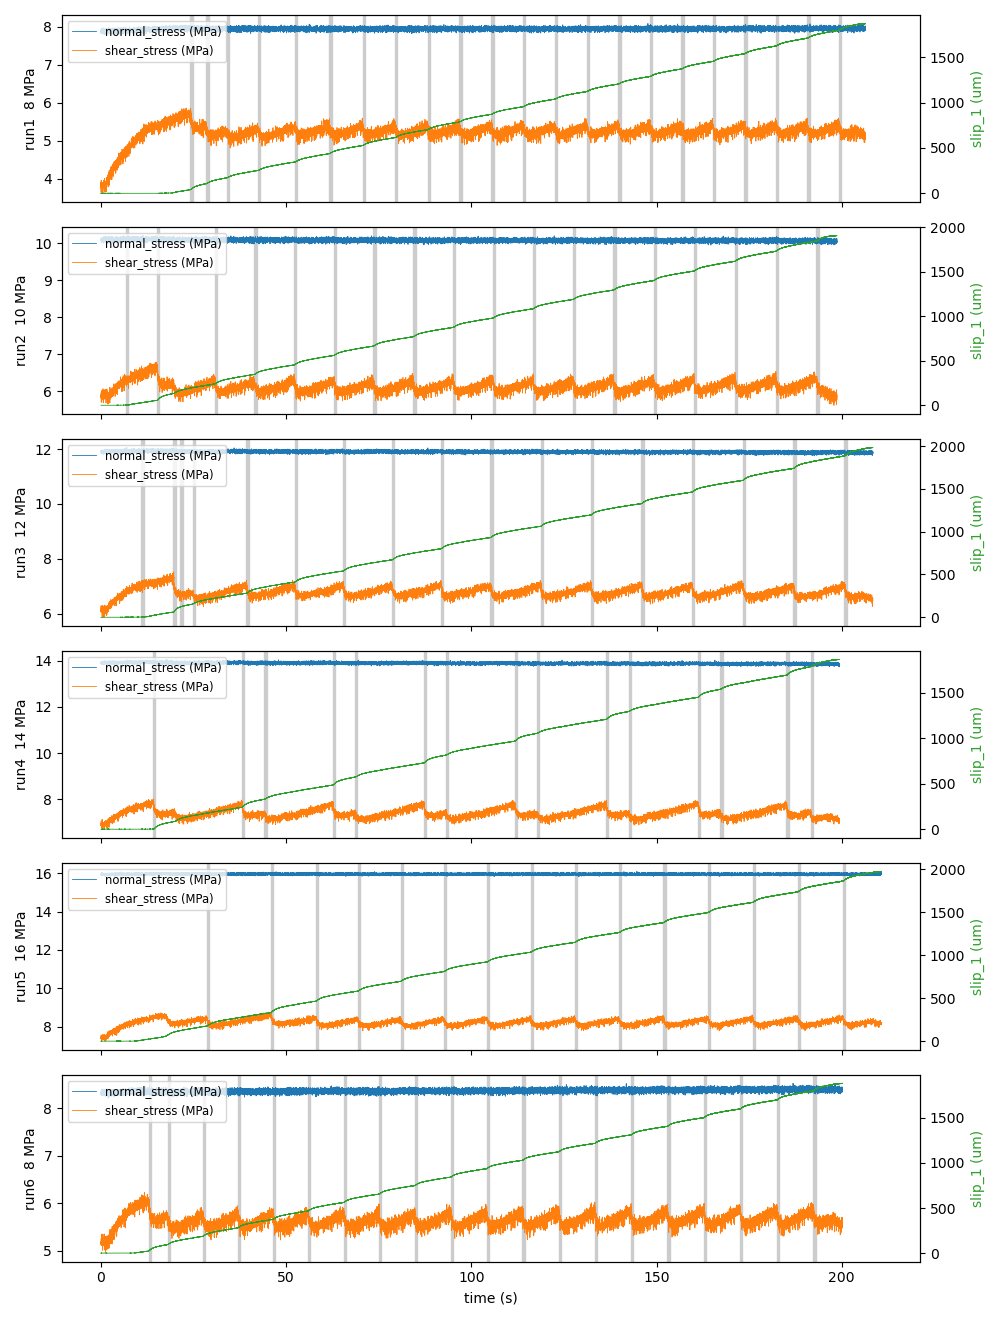

In [6]:
fig, axs = plt.subplots(len(runs), 1, figsize=(10, 2.2 * len(runs)), sharex=True)
for ax, run in zip(np.atleast_1d(axs), runs):
    ax.plot(run['time'], run['normal_stress'], lw=0.6, label='normal_stress (MPa)')
    ax.plot(run['time'], run['shear_stress'], lw=0.6, label='shear_stress (MPa)')
    ax2 = ax.twinx()
    ax2.plot(run['time'], get_channel(run, 'slip_1'), lw=0.6, color='C2')
    ax2.set_ylabel('slip_1 (um)', color='C2')
    blocks, dt0 = run['elsys']['blocks'], run['elsys']['time_offset']
    for a, b in zip(blocks['start'], blocks['end']):
        ax.axvspan(a + dt0, b + dt0, color='0.8', zorder=-10)
    ax.set_ylabel(f"{run['name']}  {run['normal_stress_level']:g} MPa" + ('  (NI)' if 'ni' in run else ''))
    ax.legend(loc='upper left', fontsize='small')
axs[-1].set_xlabel('time (s)')
fig.tight_layout()

## Clock check

One trigger block against the continuous record of the same channel, read back through the stored reference exactly as the explorer will.

Text(0.5, 1.0, 'run1: trigger block 2 vs continuous record')

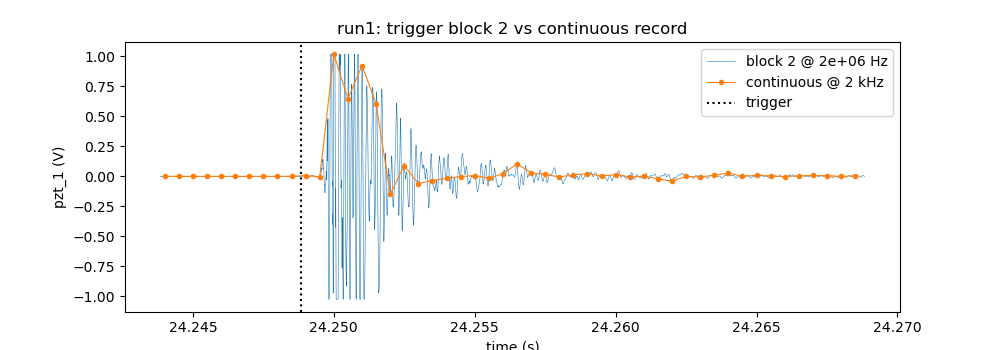

In [7]:
run_idx, block_idx, field = 0, 0, 'pzt_1'
run = runs[run_idx]
src = open_source(run['elsys'], OUTPUT_FILE.parent, run)
t_trig = src.trigger_times()[block_idx]
win = src.read_window(t_trig - 0.005, t_trig + 0.02, [field])
sel = (run['time'] >= win.time[0]) & (run['time'] <= win.time[-1])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(win.time, win.data[0], lw=0.4, label=f'block {win.block} @ {win.sample_rate:g} Hz')
ax.plot(run['time'][sel], get_channel(run, field)[sel], 'o-', ms=3, lw=0.8, label='continuous @ 2 kHz')
ax.axvline(t_trig, color='k', ls=':', label='trigger')
ax.set_xlabel('time (s)'); ax.set_ylabel(f'{field} (V)'); ax.legend(loc='upper right')
ax.set_title(f"{run['name']}: trigger block {win.block} vs continuous record")

## Experiment record and save

In [8]:
EXPERIMENT = experiment(
    't0211', runs,
    date='2026-08-28', operators=['朱宸潁'], temperature_C=21.0, humidity_percent=58.0, flow_rate_ml_min=8.0,
    acquisition=('Elsys TranAX ECR dual mode: block 1 continuous at 2 kHz, trigger blocks at 2 MHz with '
                 '0.1 s pre- and 0.5 s post-trigger; A1-A4 PZT, A5-A6 pressure, A7 LVDT, B1-B8 eddy current'),
)

In [9]:
dm = DataManager()
dm.data = EXPERIMENT
dm.save_file(OUTPUT_FILE)
print(f'{OUTPUT_FILE}  {OUTPUT_FILE.stat().st_size / 1e6:.1f} MB')

/Users/hueyke/Library/CloudStorage/SynologyDrive-data/Experiment/T0211/t0211.h5  81.5 MB


## Check the file the way the explorer loads it

In [10]:
check = DataManager()
check.load_file(OUTPUT_FILE)
rows = []
for run in check.get_data('runs'):
    row = {'run': run['name'], 'samples': len(run['time']),
           'series': len(aligned_fields(run, len(run['time']), recurse=False)),
           'trigger blocks': len(run['elsys']['blocks']['block']),
           'slip_1 end (um)': float(get_channel(run, 'slip_1')[-1])}
    for key, ref in run_sources(run).items():
        row[f'{key} file found'] = (OUTPUT_FILE.parent / ref['filename']).exists()
    rows.append(row)
pd.DataFrame(rows)

,run,samples,series,trigger blocks,slip_1 end (um),elsys file found
0,run1,412740,28,22,1869.554077,True
1,run2,397380,28,18,1908.876465,True
2,run3,416808,28,17,1984.413208,True
3,run4,398640,28,15,1866.800171,True
4,run5,421284,28,15,1974.737915,True
5,run6,400496,28,20,1881.758789,True


## Next

Open `t0211.h5` in Labquake Explorer, right-click `runs/[i]/shear_stress` → **Pick Events**: double-click the curve to
place the events, set the window and press **Extract Events**. Each event gets the run's channels around the
pick, `elsys/raw_data` (the 2 kHz voltages of the window, as in the run) and `waveform/elsys` (the PZT channels of the
whole 2 MHz trigger block that contains the event, if any).